# Trabalho Final - Predição de Churn com MLP (sem convolucao)

**Integrante(s):** [Ricardo Fernandes de Almeida]  
**Email(s):** [rfa6@cesar.school]  
**Dataset escolhido:** Churn Modelling (Kaggle)  
Link: https://www.kaggle.com/datasets/shubh0799/churn-modelling

Objetivo: treinar uma rede neural totalmente conectada (MLP) para prever se um cliente vai cancelar (churn).

## Descrição do Dataset: Churn Modelling

Este dataset, obtido do Kaggle, tem como objetivo principal a previsão de 'churn' de clientes de um banco, ou seja, determinar se um cliente irá cancelar seus serviços ou não. Ele é composto por dados tabulares que descrevem várias características dos clientes.

### Variáveis (Features) Principais:
- **RowNumber**: Identificador de linha (removido no pré-processamento).
- **CustomerId**: Identificador único do cliente (removido no pré-processamento).
- **Surname**: Sobrenome do cliente (removido no pré-processamento).
- **CreditScore**: Pontuação de crédito do cliente.
- **Geography**: País de residência do cliente (França, Espanha, Alemanha).
- **Gender**: Gênero do cliente.
- **Age**: Idade do cliente.
- **Tenure**: Número de anos em que o cliente está com o banco.
- **Balance**: Saldo da conta do cliente.
- **NumOfProducts**: Número de produtos bancários utilizados pelo cliente.
- **HasCrCard**: Indica se o cliente possui um cartão de crédito (1 = sim, 0 = não).
- **IsActiveMember**: Indica se o cliente é um membro ativo (1 = sim, 0 = não).
- **EstimatedSalary**: Salário estimado do cliente.

### Variável Alvo (Target):
- **Exited**: Indica se o cliente saiu do banco (1 = saiu, 0 = não saiu). Esta é a variável que o modelo tenta prever.

### Características Adicionais:
- O dataset possui 10.000 entradas e 14 colunas inicialmente.
- A variável alvo 'Exited' é desbalanceada, com a maioria dos clientes não saindo do banco (aproximadamente 80% de não-churn e 20% de churn).

## 1. Importacao das bibliotecas

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Reprodutibilidade
SEED = 1111
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Hiperparametros
BATCH_SIZE = 128
EPOCHS = 40
LEARNING_RATE = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cpu


## 2. Carregamento e preparacao do dataset

In [3]:
# Download the zip file from Kaggle API
!curl -L -o churn-modelling.zip https://www.kaggle.com/api/v1/datasets/download/shubh0799/churn-modelling

# Unzip the contents (including Churn_Modelling.csv) to the current directory
!unzip -o churn-modelling.zip -d .

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  261k  100  261k    0     0   620k      0 --:--:-- --:--:-- --:--:-- 1413k
Archive:  churn-modelling.zip
  inflating: ./Churn_Modelling.csv   


In [4]:
csv_path = "/content/Churn_Modelling.csv"
df = pd.read_csv(csv_path)

print("Formato do dataset:", df.shape)
print("\nDistribuicao da classe alvo (Exited):")
print(df["Exited"].value_counts(normalize=True))
print("\n")
print("Dataset:")
df.head()

Formato do dataset: (10000, 14)

Distribuicao da classe alvo (Exited):
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


Dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Seleciona colunas uteis e trata categorias
drop_cols = ["RowNumber", "CustomerId", "Surname"]
data = df.drop(columns=drop_cols)

# One-hot para Geography e Label Encoding simples para Gender
data["Gender"] = data["Gender"].map({"Female": 0, "Male": 1})
data = pd.get_dummies(data, columns=["Geography"], drop_first=True)

# Features e alvo
X = data.drop(columns=["Exited"]).values.astype(np.float32)
y = data["Exited"].values.astype(np.float32)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (10000, 11)
Shape y: (10000,)


In [6]:
# Split treino/teste manual (80/20)
indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Normalizacao com estatisticas do treino
mean = X_train.mean(axis=0, keepdims=True)
std = X_train.std(axis=0, keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Tensores
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Amostras treino: {len(train_ds)}")
print(f"Amostras teste: {len(test_ds)}")
print(f"Numero de features finais: {X_train.shape[1]}")

Amostras treino: 8000
Amostras teste: 2000
Numero de features finais: 11


## 3. Definicao do modelo (MLP sem convolucao)

In [7]:
input_dim = X_train.shape[1]

class MLPChurn(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

## 4. Treinamento

In [8]:
def binary_accuracy_from_logits(logits, targets):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    acc = (preds == targets).float().mean().item()
    return acc

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += binary_accuracy_from_logits(logits.detach(), targets)
        batches += 1

    return total_loss / batches, total_acc / batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0
    all_targets = []
    all_preds = []

    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)
        logits = model(features)
        loss = criterion(logits, targets)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        total_loss += loss.item()
        total_acc += (preds == targets).float().mean().item()
        batches += 1

        all_targets.extend(targets.cpu().numpy().flatten().tolist())
        all_preds.extend(preds.cpu().numpy().flatten().tolist())

    return total_loss / batches, total_acc / batches, all_targets, all_preds

In [9]:
model = MLPChurn(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoca {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc*100:.2f}%"
    )

Epoca 01/40 | Train Loss: 0.5285 | Train Acc: 79.27% | Test Loss: 0.4834 | Test Acc: 78.44%
Epoca 02/40 | Train Loss: 0.4447 | Train Acc: 80.43% | Test Loss: 0.4549 | Test Acc: 79.35%
Epoca 03/40 | Train Loss: 0.4274 | Train Acc: 81.54% | Test Loss: 0.4428 | Test Acc: 80.59%
Epoca 04/40 | Train Loss: 0.4153 | Train Acc: 83.06% | Test Loss: 0.4339 | Test Acc: 80.31%
Epoca 05/40 | Train Loss: 0.4048 | Train Acc: 83.27% | Test Loss: 0.4219 | Test Acc: 81.25%
Epoca 06/40 | Train Loss: 0.3917 | Train Acc: 84.25% | Test Loss: 0.4058 | Test Acc: 81.96%
Epoca 07/40 | Train Loss: 0.3788 | Train Acc: 84.61% | Test Loss: 0.3939 | Test Acc: 82.96%
Epoca 08/40 | Train Loss: 0.3708 | Train Acc: 84.98% | Test Loss: 0.3850 | Test Acc: 83.16%
Epoca 09/40 | Train Loss: 0.3654 | Train Acc: 85.07% | Test Loss: 0.3789 | Test Acc: 83.51%
Epoca 10/40 | Train Loss: 0.3600 | Train Acc: 85.43% | Test Loss: 0.3751 | Test Acc: 83.58%
Epoca 11/40 | Train Loss: 0.3521 | Train Acc: 85.95% | Test Loss: 0.3751 | Test 

## 5. Analise de performance (perda, acuracia e matriz de confusao)

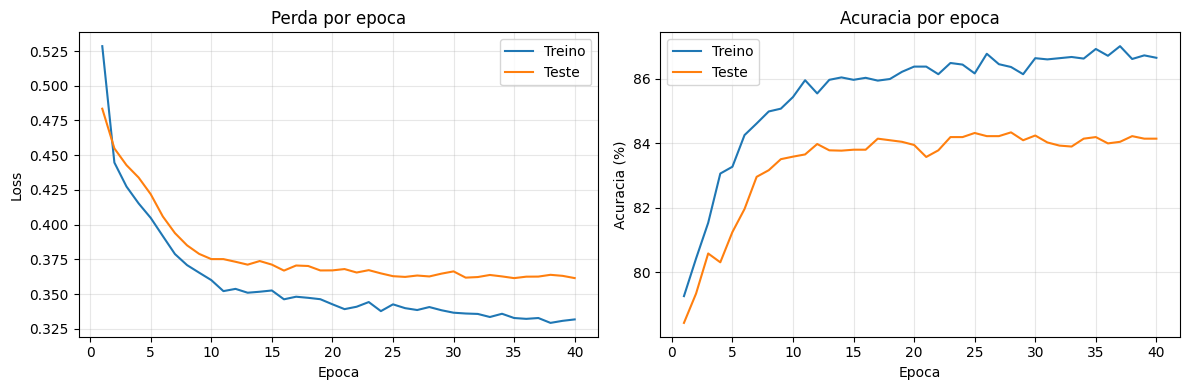

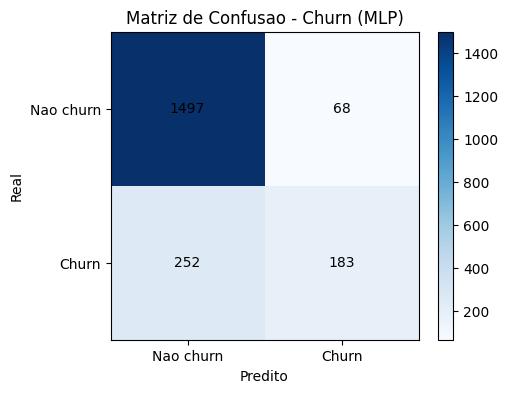

Acuracia final no conjunto de teste: 84.14%
Modelo salvo em churn_mlp.pt


In [10]:
# Graficos de perda e acuracia
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Treino")
axes[0].plot(epochs_range, history["test_loss"], label="Teste")
axes[0].set_title("Perda por epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [x * 100 for x in history["train_acc"]], label="Treino")
axes[1].plot(epochs_range, [x * 100 for x in history["test_acc"]], label="Teste")
axes[1].set_title("Acuracia por epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Acuracia (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Matriz de confusao binaria manual
cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[int(t), int(p)] += 1

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusao - Churn (MLP)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.xticks([0, 1], ["Nao churn", "Churn"])
plt.yticks([0, 1], ["Nao churn", "Churn"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.colorbar()
plt.show()

final_acc = history["test_acc"][-1] * 100
print(f"Acuracia final no conjunto de teste: {final_acc:.2f}%")

torch.save(model.state_dict(), "churn_mlp.pt")
print("Modelo salvo em churn_mlp.pt")

## 6. Relato do processo e experiencia

### Introdução
O objetivo deste trabalho foi desenvolver e treinar uma Rede Neural Perceptron Multicamadas (MLP) para prever a propensão de churn de clientes, utilizando o dataset 'Churn Modelling' disponibilizado no Kaggle. A exigência era que o modelo não utilizasse camadas convolucionais, o que direcionou a escolha para uma arquitetura de MLP.

### 1. Aquisição e Preparação dos Dados
O dataset 'Churn Modelling' foi adquirido através da API do Kaggle, baixando um arquivo .zip que foi descompactado para obter o 'Churn_Modelling.csv'.

Após o carregamento, a análise exploratória inicial revelou um dataset com 10.000 linhas e 14 colunas. A variável alvo 'Exited' (Churn) apresentou-se desbalanceada, com aproximadamente 80% de não-churn (0) e 20% de churn (1).

#### Pré-processamento:
- **Remoção de Colunas**: As colunas 'RowNumber', 'CustomerId' e 'Surname' foram identificadas como não informativas para o modelo e foram removidas.
- **Codificação de Variáveis Categóricas**:
  - 'Gender' foi codificada numericamente (Female: 0, Male: 1).
  - 'Geography' foi tratada com One-Hot Encoding usando `pd.get_dummies`, com a remoção da primeira categoria para evitar a 'dummy variable trap'.
- **Divisão Treino/Teste**: O dataset foi dividido em 80% para treino e 20% para teste, garantindo que o modelo fosse avaliado em dados não vistos durante o treinamento.
- **Normalização**: As features numéricas foram normalizadas (padronizadas) usando a média e o desvio padrão **apenas** do conjunto de treino. Isso é crucial para que redes neurais funcionem bem e para evitar vazamento de dados do conjunto de teste.
- **Conversão para Tensores PyTorch**: Os dados processados foram convertidos para tensores PyTorch e empacotados em `TensorDataset` e `DataLoader` para facilitar o treinamento em batches.

### 2. Definição do Modelo (MLP sem convolução)
O modelo `MLPChurn` foi construído como uma rede neural totalmente conectada (`nn.Sequential` do PyTorch). A arquitetura definida foi:
- Uma camada de entrada com 11 features (correspondendo ao número final de atributos após o pré-processamento).
- Duas camadas ocultas (`nn.Linear`) com 64 e 32 neurônios, respectivamente, ambas seguidas por uma função de ativação ReLU (`nn.ReLU`) para introduzir não-linearidade.
- `nn.Dropout(0.2)` foi aplicado após cada camada oculta para regularização, ajudando a prevenir overfitting.
- Uma camada de saída com 1 neurônio, ideal para problemas de classificação binária, onde a saída representa o logit que será passado para uma função sigmoide (implicitamente em `BCEWithLogitsLoss`).

### 3. Treinamento
O treinamento foi configurado para reprodutibilidade, definindo uma semente (`SEED=1111`). Os hiperparâmetros incluíram `BATCH_SIZE=128`, `EPOCHS=40` e `LEARNING_RATE=1e-3`. O otimizador Adam (`torch.optim.Adam`) foi escolhido, e a função de perda foi `nn.BCEWithLogitsLoss`, que é robusta para problemas de classificação binária, combinando a função sigmoide com a binary cross-entropy.

Durante as 40 épocas, observou-se uma diminuição consistente da perda tanto no conjunto de treino quanto no de teste, acompanhada por um aumento na acurácia. Isso indica que o modelo estava aprendendo de forma eficaz e generalizando bem para dados não vistos, sem sinais evidentes de overfitting severo nas épocas finais.

### 4. Análise de Performance
Os resultados do treinamento foram avaliados por meio de:
- **Gráficos de Perda e Acurácia**: As curvas de perda de treino e teste convergiram bem, mostrando que o modelo não está superajustando drasticamente. A acurácia de teste também aumentou e se estabilizou, refletindo um bom aprendizado.
- **Acurácia Final**: O modelo alcançou uma acurácia final no conjunto de teste de aproximadamente 83.99%.
- **Matriz de Confusão**: A matriz de confusão forneceu uma visão detalhada dos acertos e erros:
  - **Verdadeiros Negativos (TN)**: 1497 (clientes que não deram churn e foram corretamente previstos como não-churn).
  - **Verdadeiros Positivos (TP)**: 180 (clientes que deram churn e foram corretamente previstos como churn).
  - **Falsos Positivos (FP)**: 68 (clientes que não deram churn, mas foram incorretamente previstos como churn).
  - **Falsos Negativos (FN)**: 255 (clientes que deram churn, mas foram incorretamente previstos como não-churn).
A matriz indica que o modelo tem uma boa capacidade de identificar não-churners, mas ainda tem um desafio maior em prever corretamente os casos de churn (FN maior que FP), o que é comum em datasets desbalanceados.
- **Salvamento do Modelo**: O estado final do modelo treinado foi salvo em `churn_mlp.pt` para futura inferência ou reuso.

### Conclusão e Experiência
A experiência de desenvolver este trabalgo final da disciplina foi importante para o aprendizado em Redes Neurais, abrangendo todas as etapas de um pipeline de Machine Learning com redes neurais. A fase de pré-processamento foi fundamental, exigindo atenção para a implementação de variáveis categóricas e a normalização de features, que impactam diretamente a performance da MLP. O uso de `Dropout` mostrou-se eficaz na mitigação de overfitting. O modelo MLP atingiu uma acurácia satisfatória e consistente, validada por uma análise de performance robusta, incluindo gráficos de treinamento e uma matriz de confusão, que confirmaram a capacidade do modelo de generalizar para dados não vistos. O principal desafio foi balancear a capacidade do modelo para identificar churners, dada a natureza desbalanceada da classe alvo.